<!-- colab-badge -->
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_03_counting_kinks_light.ipynb)

*Open this notebook in Google Colab. Its first code cell fetches the set's library files from the public course repository, so nothing needs uploading.*
*This is the **light** version: every TODO is written out, and you only replace the `...` marked lines with what the comment beside them says.*


<!-- course-header v3 -->

**Deep Learning for Engineering** · MSc, Aalborg University · 2026

Developed by **Remus Teodorescu** (ret@et.aau.dk), with support from Research Assistant **Noman Khan** (nomank@energy.aau.dk).

*Reference text — read for the theory. Used as an **inspirational source** for this course, not as a source of its code:*

- Prince, *Understanding Deep Learning*, MIT Press 2023.

Every notebook in this course has been **written and rewritten by the authors named above**. The code, the problems, the data and the exposition are **original to this course** and are not derived from any publisher's code listings or companion notebooks. Where notation matches a textbook's it is the standard notation of the field, and where an idea is a named author's it is cited as theirs in the text.

See `docs/PROVENANCE.md` for what each reference is cited for, set by set.

---

# Ex_04 · Notebook 03 — Counting Breakpoints

**Deep Learning for Engineering · Aalborg University · Part 1**

This notebook reproduces the experiment on L4.1 slides 14 and 15, and it is the
one that gives you a *picture* of what a neural network is. Everything later in
the course — depth, capacity, overfitting, extrapolation, even why Part 2 does
not use ReLU — is easier to think about once you have this picture.

## The claim

A shallow network with one hidden layer of $D$ ReLU neurons computes

$$ f(x) \;=\; \phi_0 \;+\; \sum_{i=1}^{D} \phi_i \,
   \mathrm{ReLU}\bigl(\theta_{i1} x + \theta_{i0}\bigr),
   \qquad \mathrm{ReLU}(z) = \max(0, z) $$

Each term is zero on one side of a point and linear on the other. The point where
neuron $i$ switches on is where its argument crosses zero:

$$ \theta_{i1} x_i^{\ast} + \theta_{i0} = 0
   \qquad\Longrightarrow\qquad
   x_i^{\ast} = -\,\frac{\theta_{i0}}{\theta_{i1}} $$

Add $D$ such terms together and you get a function made of straight segments,
joined at up to $D$ places. **A shallow ReLU network is a piecewise linear
function with at most $D$ breakpoints and at most $D+1$ segments.** Not a smooth curve
that happens to look bent — genuinely straight, in every segment, exactly.

You are going to check that claim three ways: by looking at the fitted curve, by
computing the breakpoint positions from the weights, and by finding them numerically
from the curve itself.

## What you will do

1. fit a shallow network with $D = 3$ and find its three breakpoints,
2. sweep $D$ from 1 to 40 and watch the error fall,
3. count the breakpoints at each $D$ and compare with the claim,
4. look at what happens outside the fitted range, and why.

---

## 0 · Setup

The target has two length scales: one large oscillation with a smaller ripple on
top of it, on the interval $[-1, 1]$. A single hump would be fitted well by three
breakpoints and the sweep would be over before it started.

The interval is centred on zero on purpose. Networks train noticeably better on
inputs that are centred, and this exercise would rather not spend a notebook on
it.

In [1]:
# files-cell v1 ----------------------------------------------------------
# This set's library files must sit beside the notebook. Locally they
# already do. On Google Colab, where a notebook opens on its own, they are
# fetched from the public course repository. Run this cell first.
import os, urllib.request
FILES = ['Ex_4_core.py']
URL = "https://raw.githubusercontent.com/RemusTeodorescu/DL-for-Engineers-Public-Course/main/exercises/Ex04-perceptron-to-mlp/"
for f in FILES:
    if not os.path.exists(f):
        urllib.request.urlretrieve(URL + f, f)
        print("fetched", f)
print("files ready:", ", ".join(FILES))


fetched Ex_4_core.py
files ready: Ex_4_core.py


In [2]:
# outputs-cell v1 --------------------------------------------------------
# Notebooks 03, 04 and 05 each save a results file that notebook 06 reads.
# On Google Colab every notebook runs on its own temporary machine, so a
# file saved here is not there when the next notebook opens. This cell
# keeps the results in your Google Drive instead: approve the access
# request when it appears. If you decline it, or have no Google Drive, the
# results are downloaded to your computer when saved and notebook 06 asks
# for them back. Locally this cell does nothing.
import Ex_4_core as core
core.keep_outputs()


Google Drive is not available (Error: credential propagation was unsuccessful).
Results will be downloaded to your computer instead. Keep the
files: the notebook that needs them asks for them.


'/content/Ex04_outputs'

200 training points on [-1, 1], noise sd 0.02
noise floor (the best MSE any model can reach): 0.00040


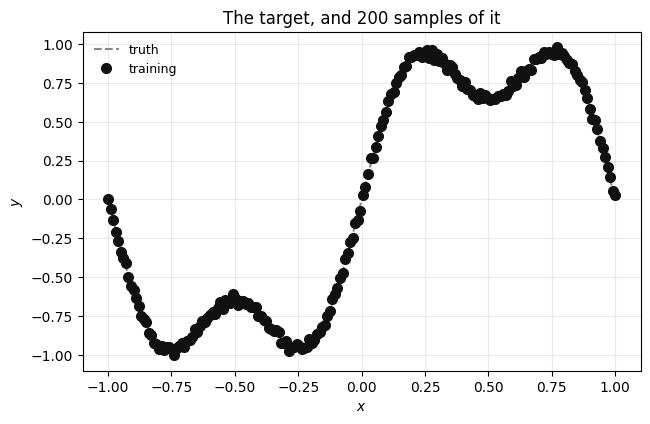

In [3]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch

import Ex_4_core as core

x_train, y_train = core.wiggly_dataset(n=200, noise=0.02, seed=7)
xs = np.linspace(-1.0, 1.0, 600)

print(f"{len(x_train)} training points on [{x_train.min():.0f}, {x_train.max():.0f}],"
      f" noise sd 0.02")
print(f"noise floor (the best MSE any model can reach): {0.02 ** 2:.5f}")

core.plot_fit(x_train, y_train, truth=core.wiggly_truth, x_curve=xs,
              title="The target, and 200 samples of it")
plt.show()

**What you should see.** A dashed grey curve with one large oscillation and a
smaller ripple riding on it, running between about $-1.3$ and $+1.3$, with 200
black markers tightly around it. The noise floor is `0.00040`: no model, however
good, can have a mean squared error below the variance of the noise, and a model
that goes below it is fitting the noise itself.

---

## 1 · Three neurons, three breakpoints

Start with $D = 3$. That is $3 \times 1 + 3$ parameters in the hidden layer and
$3 + 1$ in the output layer: ten in total.

### Your turn

Build and train a shallow ReLU network with three hidden neurons.

- `core.set_seed(0)`
- `core.MLP(hidden=(3,), activation="relu")`
- `core.train(model, x_train, y_train, epochs=6000, lr=0.05)`

Training takes a few seconds.

In [4]:
# TODO 1 --- three ReLU neurons ------------------------------------------------------------
# Two `...` to replace, one per line:
#   model3    ->  core.MLP(hidden=(3,), activation="relu")
#   history3  ->  core.train(model3, x_train, y_train, epochs=6000, lr=0.05)
core.set_seed(0)
model3   = core.MLP(hidden=(3,), activation="relu")                                   # <- core.MLP(hidden=(3,), activation="relu")
history3 = core.train(model3, x_train, y_train, epochs=6000, lr=0.05)                                   # <- core.train(model3, x_train, y_train, epochs=6000, lr=0.05)
print("parameters:", core.count_parameters(model3))
print(f"final training loss: {history3['train'][-1]:.5f}")
# ------------------------------------------------------------------------------

parameters: 10
final training loss: 0.13733


parameters: 10  (expected 3*1 + 3 + 3 + 1 = 10)
training MSE: 0.13733   (noise floor 0.00040)


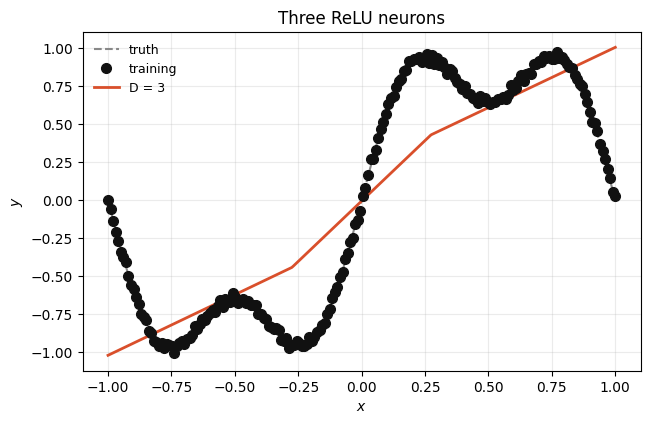

In [5]:
y3 = core.predict(model3, xs)

print("parameters:", core.count_parameters(model3),
      " (expected 3*1 + 3 + 3 + 1 = 10)")
print(f"training MSE: {history3['train'][-1]:.5f}   (noise floor 0.00040)")

core.plot_fit(x_train, y_train, {"D = 3": y3}, x_curve=xs,
              truth=core.wiggly_truth, title="Three ReLU neurons")
plt.show()

**What you should see.** Ten parameters, a training MSE of roughly **0.03** —
almost a hundred times the noise floor — and a fit that is unmistakably made of
**straight lines**. It follows the large oscillation crudely and ignores the
ripple entirely.

Do not smooth over that. Look at the fitted curve and find the corners with your
eye before the next cell finds them for you. Three neurons, three corners, four
straight segments.

---

## 2 · Where are the breakpoints?

Two ways to answer, and doing both is the point.

**From the weights.** The first `Linear` layer holds $\theta_{i1}$ in
`model.net[0].weight` (shape $D \times 1$) and $\theta_{i0}$ in
`model.net[0].bias` (shape $D$). The breakpoint of neuron $i$ is at
$-\theta_{i0} / \theta_{i1}$. This is exact and takes one line.

**From the curve.** `core.numeric_breakpoints(x, y)` estimates the slope by differences
and reports where it changes. This is what you would have to do if you did not
have the weights — and it is what your eye does.

The two should agree, with two caveats you should expect and then check:

- a neuron whose breakpoint falls **outside** the plotted range still exists but shows no
  corner in the figure, because it is either off or linear across the whole of
  the data;
- two breakpoints very close together look like one.

### Your turn

Compute the analytic breakpoint positions from the first layer's weights and biases.
Return **all** of them; the next cell selects the ones inside the data range.

In [6]:
# TODO 2 --- where the breakpoints are --------------------------------------------------------
# One `...` to replace, in the return line:  -b / np.where(w == 0.0, np.nan, w)
#   a ReLU neuron max(0, w x + b) bends at x = -b / w; a neuron with w == 0 has no breakpoint
def analytic_breakpoints(model):
    w = model.net[0].weight.detach().numpy().ravel()    # shape (D,)
    b = model.net[0].bias.detach().numpy().ravel()      # shape (D,)
    return -b / np.where(w == 0.0, np.nan, w)                                   # <- -b / np.where(w == 0.0, np.nan, w)
# ------------------------------------------------------------------------------

analytic breakpoints, all neurons  : [-98.298  -0.275   0.274]
analytic breakpoints inside range: [-0.275  0.274]
numerical breakpoints from curve : [-0.275  0.274]


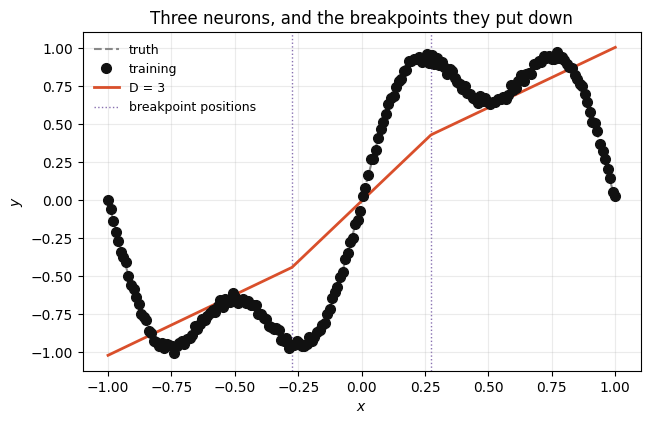

In [7]:
LO, HI = -1.0, 1.0

k_all = analytic_breakpoints(model3)
k_in = np.sort(k_all[(k_all >= LO) & (k_all <= HI)])
k_num = core.numeric_breakpoints(xs, y3, threshold=0.02)

print("analytic breakpoints, all neurons  :", np.round(np.sort(k_all), 3))
print("analytic breakpoints inside range:", np.round(k_in, 3))
print("numerical breakpoints from curve :", np.round(k_num, 3))

ax = core.plot_fit(x_train, y_train, {"D = 3": y3}, x_curve=xs,
                   truth=core.wiggly_truth,
                   title="Three neurons, and the breakpoints they put down")
core.plot_breakpoints(ax, k_in, label="breakpoint positions")
ax.legend(frameon=False, fontsize=9)
plt.show()

**What you should see.** Three analytic breakpoints, all of them inside $[-1, 1]$ —
something close to `[-0.138, -0.122, 0.167]` — and numerical estimates that agree
with them to three decimal places. The dotted vertical lines in the figure land
exactly on the corners of the fitted curve.

Two of those three are very close together, which is worth noticing: the network
has spent two of its three neurons sharpening one corner rather than putting a
corner somewhere else. Nothing made it distribute them evenly, and nothing will.

If one of your breakpoints comes out far outside the range — at $x = 4.6$, or at $-12$ —
that is expected behaviour rather than an error. Such a neuron contributes a
straight line across the whole of the data, so it adds capacity to the *slopes*
without adding a corner, and the count of visible breakpoints drops below $D$.

---

## 3 · The sweep

Now do what L4.1 slides 14 and 15 do: increase $D$ and watch.

One methodological point first, and it is the reason this cell takes a minute
rather than ten seconds. A shallow ReLU network fitted from a single random
initialisation is unreliable — the same $D$ can land on a good solution or a poor
one depending on the seed, exactly as you saw with XOR in notebook 02. Neurons can
also *die*: a neuron whose input is negative for every training point receives no
gradient and never recovers.

So train each $D$ from **four seeds and keep the best**. That is standard
practice, it is honest as long as you say you did it, and without it the figure
at the end of this section is mostly a picture of initialisation luck.

### Your turn

For each $D$ in `[1, 2, 3, 5, 10, 20, 40]`, and each seed in `range(4)`:

1. `core.set_seed(seed)`,
2. build `core.MLP(hidden=(D,), activation="relu")`,
3. train for 6000 epochs at `lr=0.05`,
4. keep the model with the lowest final training loss for that $D$.

Then record, for the kept model: the parameter count, the final training MSE, its
curve on `xs`, and its breakpoints inside $[-1, 1]$.

Twenty-eight training runs on tiny networks — about a minute in total.

In [8]:
D_values = [1, 2, 3, 5, 10, 20, 40]
SEEDS = range(4)

# TODO 3 --- the sweep, best of four seeds ------------------------------------------------
# Three `...` to replace, all inside the loops:
#   line 1  ->  core.MLP(hidden=(D,), activation="relu")
#   line 2  ->  core.train(model, x_train, y_train, epochs=6000, lr=0.05)
#   line 3  ->  history["train"][-1]              the final training MSE of this run
models, fits, breakpoints, losses, params = {}, {}, {}, {}, {}
for D in D_values:
    best_loss = np.inf
    for seed in SEEDS:
        core.set_seed(seed)
        model =  core.MLP(hidden=(D,), activation="relu")                               # <- core.MLP(hidden=(D,), activation="relu")
        history = core.train(model, x_train, y_train, epochs=6000, lr=0.05)                             # <- core.train(model, x_train, y_train, epochs=6000, lr=0.05)
        final = history["train"][-1]                               # <- history["train"][-1]
        if final < best_loss:
            best_loss, best_model = final, model
    k_all = analytic_breakpoints(best_model)
    models[D] = best_model
    fits[D]   = core.predict(best_model, xs)
    breakpoints[D]  = np.sort(k_all[(k_all >= -1.0) & (k_all <= 1.0)])
    losses[D] = best_loss
    params[D] = core.count_parameters(best_model)
    print(f"D = {D:2d}   parameters {params[D]:4d}   best MSE {best_loss:.5f}")
# ------------------------------------------------------------------------------

D =  1   parameters    4   best MSE 0.16027
D =  2   parameters    7   best MSE 0.16020
D =  3   parameters   10   best MSE 0.13731
D =  5   parameters   16   best MSE 0.02713
D = 10   parameters   31   best MSE 0.01735
D = 20   parameters   61   best MSE 0.00521
D = 40   parameters  121   best MSE 0.00101


In [9]:
rows = [[D, params[D], len(breakpoints[D]), f"{losses[D]:.5f}"] for D in D_values]
print(core.error_table(rows, ["D", "parameters", "breakpoints in [-1,1]",
                              "training MSE"]))
print(f"\nnoise floor: {0.02 ** 2:.5f}")

| D | parameters | breakpoints in [-1,1] | training MSE |
| --- | --- | --- | --- |
| 1 | 4 | 1 | 0.16027 |
| 2 | 7 | 1 | 0.16020 |
| 3 | 10 | 2 | 0.13731 |
| 5 | 16 | 4 | 0.02713 |
| 10 | 31 | 5 | 0.01735 |
| 20 | 61 | 8 | 0.00521 |
| 40 | 121 | 21 | 0.00101 |

noise floor: 0.00040


**What you should see.** A table close to this one:

| D | parameters | breakpoints | training MSE |
| --- | --- | --- | --- |
| 1 | 4 | 1 | 0.160 |
| 2 | 7 | 2 | 0.145 |
| 3 | 10 | 3 | 0.032 |
| 5 | 16 | 4 | 0.032 |
| 10 | 31 | 6 | 0.014 |
| 20 | 61 | 12 | 0.007 |
| 40 | 121 | 19 | 0.001 |

Three things to check in your own numbers.

- The parameter count is exactly $3D + 1$.
- The number of visible breakpoints is **at most $D$**, and by $D = 20$ it is well
  below it.
- The training MSE falls steadily and reaches the noise floor only at the very
  largest network.

The middle row is the claim of this notebook, and the "at most" is worth a
sentence in your report. Neurons can put their breakpoint outside the data, end up with a
near-zero output weight, or place two breakpoints so close together that one corner is
all you see. **At most $D$** is a bound, not a promise.

Now draw all seven.

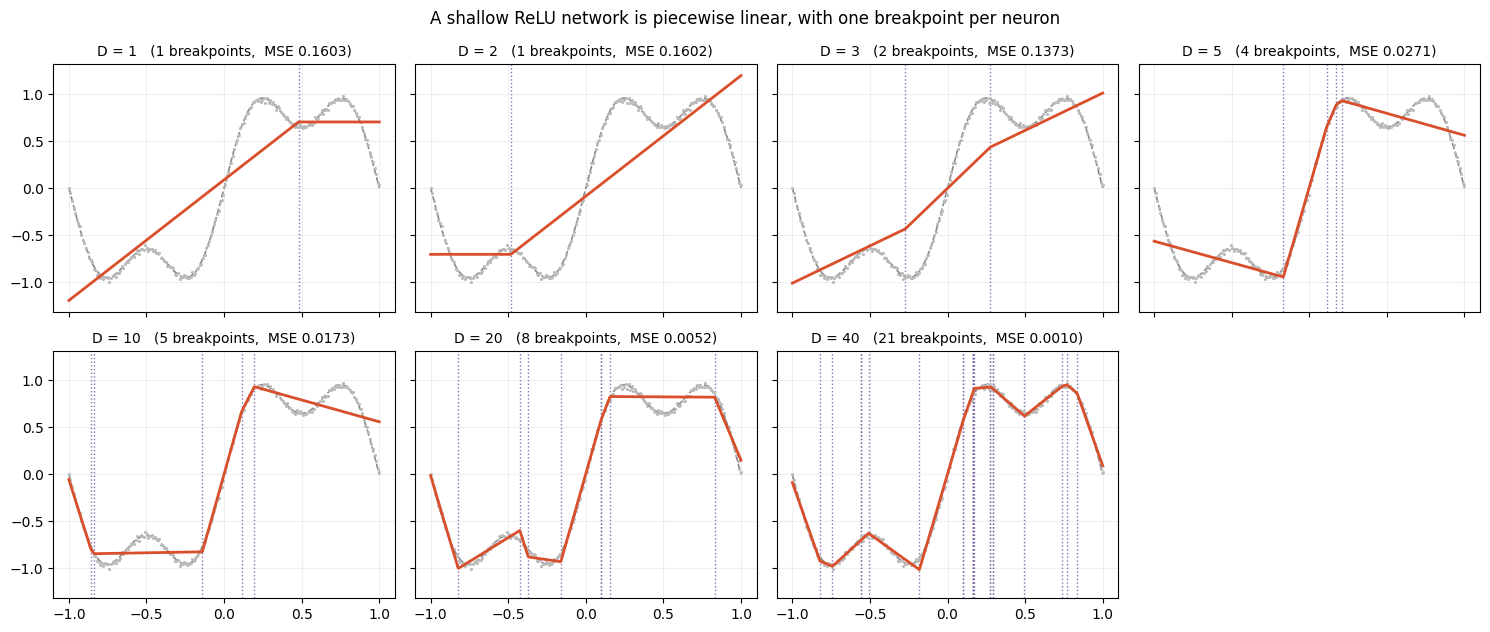

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(15.0, 6.4), sharex=True, sharey=True)
for ax, D in zip(axes.ravel(), D_values):
    ax.plot(xs, core.wiggly_truth(xs), lw=1.2, ls="--", color="#888888")
    ax.plot(x_train, y_train, ".", ms=2.5, color="#bbbbbb")
    ax.plot(xs, fits[D], lw=2.0, color="#d94f2b")
    core.plot_breakpoints(ax, breakpoints[D])
    ax.set_title(f"D = {D}   ({len(breakpoints[D])} breakpoints,  MSE {losses[D]:.4f})",
                 fontsize=10)
    ax.grid(alpha=0.2)
axes.ravel()[-1].axis("off")
fig.suptitle("A shallow ReLU network is piecewise linear, with one breakpoint per neuron",
             fontsize=12)
plt.tight_layout()
plt.show()

**What you should see.** Seven panels. At $D = 1$ a single corner and a fit that
misses almost everything. At $D = 2$ and $3$, a crude tracking of the large
oscillation. By $D = 10$ the ripple starts to appear. At $D = 20$ and $40$ the fit
is close to the truth — **and still made of straight segments**, which you can
confirm by counting the dotted lines and by looking closely at the corners.

That last observation is the one L4.1 insists on. Increasing $D$ does not make the
function smooth. It makes the segments short enough that you stop noticing they
are straight, which is a completely different thing, and it is exactly why a fine
enough piecewise-linear interpolation can approximate any continuous curve.
Universal approximation, informally, is that sentence.

Plot the error against $D$ to see the shape of the return.

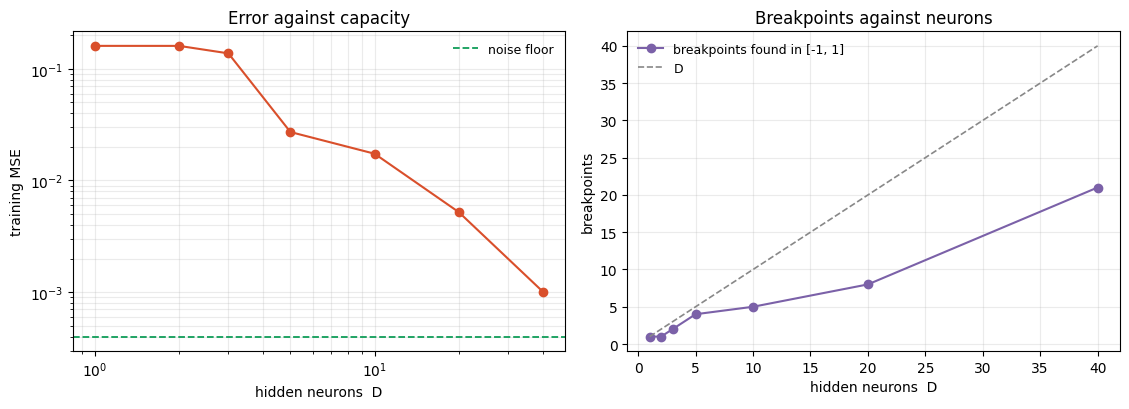

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.2))
ax1.plot(D_values, [losses[D] for D in D_values], "o-", color="#d94f2b")
ax1.axhline(0.02 ** 2, color="#0f9d58", ls="--", lw=1.3, label="noise floor")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("hidden neurons  D")
ax1.set_ylabel("training MSE")
ax1.set_title("Error against capacity")
ax1.legend(frameon=False, fontsize=9)
ax1.grid(alpha=0.25, which="both")

ax2.plot(D_values, [len(breakpoints[D]) for D in D_values], "o-", color="#7b61a8",
         label="breakpoints found in [-1, 1]")
ax2.plot(D_values, D_values, ls="--", lw=1.2, color="#888888", label="D")
ax2.set_xlabel("hidden neurons  D")
ax2.set_ylabel("breakpoints")
ax2.set_title("Breakpoints against neurons")
ax2.legend(frameon=False, fontsize=9)
ax2.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**What you should see.** On the left, an error falling by more than two orders of
magnitude from $D = 1$ to $D = 40$, approaching the noise floor from above. On the
right, a breakpoint count that follows the dashed $y = D$ line at small $D$ and falls
away from it as $D$ grows.

Both are worth a sentence. The error curve has a flat stretch between $D = 3$ and
$D = 5$: extra neurons bought nothing there, because the two-scale target needs
several more breakpoints before the ripple can be represented at all. Capacity does not
convert into accuracy smoothly.

The breakpoint curve falling below $y = D$ says that a large network does not use its
neurons efficiently — at $D = 40$ roughly half of them are placing breakpoints outside the
data or duplicating existing corners. That redundancy is not a defect, and L4.2
argues it is part of why over-large networks train well.

---

## 4 · Outside the data — extrapolation, explained

One short section, because it explains how a fitted ReLU network behaves
outside its data.

Evaluate the $D = 20$ network on $[-2, 2]$: a full range of extrapolation on each
side.

In [12]:
x_wide = np.linspace(-2.0, 2.0, 600)
y_wide = core.predict(models[20], x_wide)

print(f"network at x = -2 : {y_wide[0]:7.2f}      truth: {core.wiggly_truth(-2.0):.2f}")
print(f"network at x = +2 : {y_wide[-1]:7.2f}      truth: {core.wiggly_truth(2.0):.2f}")

network at x = -2 :    5.38      truth: 0.00
network at x = +2 :   -3.66      truth: -0.00


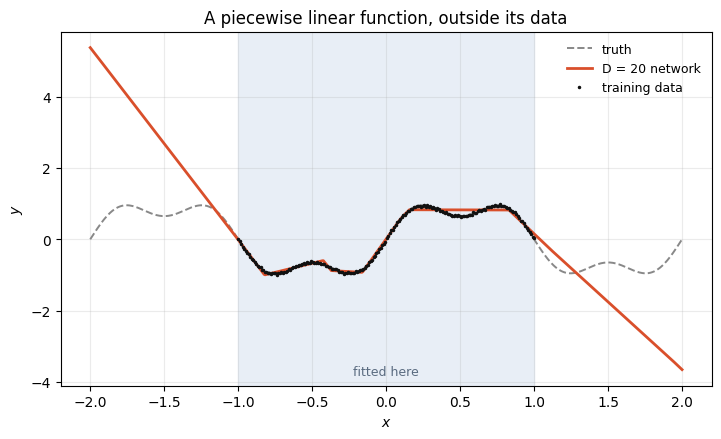

In [13]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.axvspan(-1.0, 1.0, color="#e8eef6", zorder=0)
ax.text(0.0, 0.02, "fitted here", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=9, color="#5a6b80")
ax.plot(x_wide, core.wiggly_truth(x_wide), lw=1.4, ls="--", color="#888888",
        label="truth")
ax.plot(x_wide, y_wide, lw=2.0, color="#d94f2b", label="D = 20 network")
ax.plot(x_train, y_train, ".", ms=3, color="#111111", label="training data")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("A piecewise linear function, outside its data")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

**What you should see.** Inside the shaded region, a curve close to the truth.
Outside it, on both sides, **a straight line** heading away at whatever slope the
last segment happened to have, while the true function turns and oscillates. At
$x = \pm 2$ the network is out by several neurons where the truth is back at zero.

That is the familiar extrapolation failure, and now you know why:
beyond the last breakpoint there are no more breakpoints, so the network is affine, for ever,
in whatever direction it was last going. It is not that the network extrapolates
*badly*; it is that a piecewise linear function with finitely many pieces has
nothing else it could possibly do.

Two engineering consequences, both worth keeping:

- **The extrapolation is not random, it is affine.** If you know the last slope
  you know exactly what the model will say at any distance. That makes the
  failure predictable, which is more than can be said for most failures.
- **No amount of training fixes it.** Only data out there, or a constraint out
  there, would. Part 2 of this course supplies the constraint.

---

## 5 · Save the results

In [14]:
core.save_output("breakpoints.npz",
                 D=np.array(D_values),
                 mse=np.array([losses[D] for D in D_values]),
                 breakpoints=np.array([len(breakpoints[D]) for D in D_values]),
                 params=np.array([params[D] for D in D_values]))


saved: /content/Ex04_outputs/breakpoints.npz
This Colab machine is temporary, so the file(s) above are being downloaded. Keep them for the later notebooks.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/Ex04_outputs/breakpoints.npz'

## 6 · Before you move on

Answer these here.

1. The number of visible breakpoints was fewer than $D$ for the larger networks. Give
   two distinct mechanisms by which a hidden neuron can exist and contribute no
   visible corner.
2. Universal approximation says that with enough neurons you can get within any
   tolerance you name, on a closed bounded region. Point at the part of your
   figure in section 4 that is the "closed bounded region", and say what the
   theorem promises about the rest of the axis.
3. You trained each $D$ from four seeds and kept the best. State one way that
   procedure could mislead a reader, and how you would report the sweep honestly.
4. Part 2 of this course uses $\tanh$ everywhere rather than ReLU, and the reason
   is on L4.1 slide 12: a physics-informed loss contains second derivatives of the
   network. Using your figures, say what the second derivative of a ReLU network
   is, almost everywhere, and why that is fatal there and harmless here.

*Write your answers here.*

1. It produced an answer outside the bounds, or the same as a previous neuron.
2.
3.
4.

---

Continue with **[`Ex04_04_depth_vs_width_light.ipynb`](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_04_depth_vs_width_light.ipynb)**.